# Real-time Communication

In [3]:
import networkx as nx 
from dataXplorer import JupyterClient
from dataXplorer import AnalysisToolkit, SessionManager, TextureGenerator, ProjectFileManager, VisualizerSyncer

In [4]:
# run backend (server) using buildandrun powershell script
client = JupyterClient()

#client.disconnect()

✅ Connected to /main


✅ Connected to /main
✅ Connected to /main
✅ Connected to /main


### OPTIONAL : Create new Project  (if project is not in list)

In [ ]:
import pandas as pd

edge_df = pd.read_csv(
    'temp-files/PPI_joel/human_ppi.tsv',
    sep = '\t',
    #compression = 'gzip',
    header = None,
    names = ['A', 'B']
)
edges = []
for _, row in edge_df.iterrows():
    edges.append(
        (row.A, row.B)
    )

G = nx.Graph()
G.add_edges_from(edges)

# use only the largest connected component
def largest_connected_component(G):
    largest_cc = max(nx.connected_components(G), key=len)
    return largest_cc

# use only the largest connected component
lcc_nodes = largest_connected_component(G)
G = nx.induced_subgraph(G, lcc_nodes)

In [ ]:
G.nodes()

nodenames = list(G.nodes())

In [ ]:
#number of nodes
n_nodes = G.number_of_nodes()
print(f"Number of nodes in the PPI network: {n_nodes}")
#number of edges
n_edges = G.number_of_edges()
print(f"Number of edges in the PPI network: {n_edges}")


In [ ]:
G.graph['projectname'] = "PPI_joel_daniel_aryan_test_1"
G.graph['info'] = "."

blueblue = "#0739ff"
d_nodecolors_hex = dict(zip(G.nodes(),[blueblue]*len(G.nodes()))) 
nx.set_node_attributes(G, d_nodecolors_hex, 'nodecolor')

lightblue = "#7994ff"
l_linkcolors_hex = lightblue
nx.set_edge_attributes(G, l_linkcolors_hex, 'linkcolor')

In [ ]:
# make a layout 

# if precalculated e.g.
#pos_3D = nx.get_node_attributes(G, 'pos')

# an example layouts
import cartoGRAPHs as cg
pos_3D = cg.layout_global_umap(G, dim=3, n_neighbors=10, min_dist=0.1)
pos_3D_ = {key: list(value) for key, value in pos_3D.items()}
#posG = nx.spring_layout(G, dim=3)
#pos_random = nx.random_layout(G, dim=3, seed=42)
#pos_random_3D = dict(zip(G.nodes(),[i.tolist() for i in pos_random.values()])) # 3D positions


In [54]:
G.graph["layoutname"] ='layout-initial'
nx.set_node_attributes(G, pos_3D_, name='pos')

In [55]:
import nx2json as nx2j 
nx2j.create_project(G)

Successfully created the directory static/projects/PPI_joel_daniel_aryan_test_1 
PROGRESS: loaded graph JSON...
PROGRESS: stored graph data...
PROGRESS: stored layouts...
PROGRESS: stored node info...
PROGRESS: made node position textures...
PROGRESS: made textures for node colors...
PROGRESS: made textures for links...
PROGRESS: made textures for linkcolors...
PROGRESS: writing json files for project and nodes...
Project created successfully.


### Access Project list and select one by ID

In [5]:
# see if new project is in projectlist
import GlobalData as GD

allprojects_updated = []
for i, proj in enumerate(GD.listProjects()):
    allprojects_updated.append((i,proj))
allprojects_updated

[(0, '0_SpatialPPI_Elias'),
 (1, 'AE_Memes_2022'),
 (2, 'ARS23_memes'),
 (3, 'ByzNet-1400-people-only'),
 (4, 'ByzNet_PxL'),
 (5, 'CDK5'),
 (6, 'CircLadderGraph-xsmall'),
 (7, 'diffusion'),
 (8, 'JSON_autocore'),
 (9, 'JSON_barbellgraph'),
 (10, 'JSON_Zachary'),
 (11, 'Microplastics_HumanHealth'),
 (12, 'Pesticides_HumanHealth'),
 (13, 'PG_NEW'),
 (14, 'Powergrid_Europe'),
 (15, 'PPI_brain_infarction'),
 (16, 'PPI_joel_daniel_aryan'),
 (17, 'PPI_joel_daniel_aryan_C'),
 (18, 'PPI_joel_daniel_aryan_test_1'),
 (19, 'PPI_networkcartoGRAPHs'),
 (20, 'Realtime-project'),
 (21, 'Sphere_Torus'),
 (22, 'Teapot'),
 (23, 'Template'),
 (24, 'test'),
 (25, 'TheMandelbulb_edges'),
 (26, 'XX')]

In [7]:
# select a project to work with
sel_id = 17
sel_name = allprojects_updated[sel_id][1]

# load the project data
session = SessionManager(sel_id, sel_name, client)
session.load_graph_from_project()
session.reload_project()

# initialize 
file_mgr = ProjectFileManager(session)
tex_gen = TextureGenerator(session)
syncer = VisualizerSyncer(session)

Session Graph loaded from project folder. 
Project name:  PPI_joel_daniel_aryan_C
Data: Nodes: 18176 Links: 476727


✅ Connected to /main
✅ Connected to /main
✅ Connected to /main


In [8]:
G = session.load_graph_from_project()

# get nodenames from node attributes
nodenames_session = [data.get("name") for _, data in G.nodes(data=True)]
nodenames_session = [name for name in nodenames_session if name is not None]

# rename nodes back to original names
mapping = dict(zip(G.nodes(), nodenames_session))
G = nx.relabel_nodes(G, mapping)
G.nodes()

Session Graph loaded from project folder. 
Project name:  PPI_joel_daniel_aryan_C
Data: Nodes: 18176 Links: 476727


NodeView(('CIC', 'GTPBP3', 'KLF5', 'TRIM22', 'SOX15', 'ELF4', 'ELK3', 'SETD2', 'SOX6', 'YWHAQ', 'FOXQ1', 'SOX5', 'PAX7', 'SP7', 'HNF4A', 'KLHL22', 'ERG', 'S100P', 'TEAD1', 'PICK1', 'NFIX', 'PAX6', 'SOX17', 'TLX2', 'IRF8', 'RAVER1', 'GABPB1', 'NFIC', 'YWHAB', 'GATA2', 'LHX3', 'FOS', 'EN1', 'MAD2L1', 'KLF3', 'TBXT', 'TLX3', 'PAX9', 'NFYC', 'TBR1', 'SEC62', 'LHX6', 'CENPJ', 'PRDM1', 'HNF1A', 'SOX9', 'PYCR2', 'TLX1', 'CSNK2B', 'YWHAZ', 'RAD50', 'VSX1', 'IRF4', 'LHX4', 'PAX8', 'ZBTB18', 'GATA3', 'FOXL1', 'PLK1', 'YWHAE', 'MYB', 'ESR1', 'POLR1H', 'GOLGA2', 'PAX2', 'AR', 'GCM1', 'LHX2', 'FEV', 'SOX2', 'FOXK2', 'YWHAG', 'SOX10', 'HNF1B', 'ATXN1', 'KLF12', 'KLF15', 'NFIA', 'EYA2', 'YWHAH', 'NFIB', 'KLF8', 'PRPF3', 'PPP1R18', 'ETFRF1', 'RASL10B', 'MRPL21', 'DPPA4', 'SERTAD3', 'GPR45', 'MBD3L1', 'GNE', 'TARDBP', 'PYCR1', 'AGR2', 'RALY', 'PIKFYVE', 'MEOX2', 'MESD', 'INCA1', 'BEND7', 'PTAFR', 'MGST3', 'RCN1', 'COPS5', 'YARS2', 'SPINT2', 'IMMP2L', 'ZNF774', 'CAPN3', 'RAMP2', 'PDK1', 'KLK14', 'SINHCA

### Manipulate node colors / positions / link colors 

In [9]:
# initialize analysis toolkit
tools = AnalysisToolkit(session, tex_gen, syncer, file_mgr)

In [10]:
import pandas as pd
# read gene list from csv
symbol_pep_3 = pd.read_csv('temp-files/PPI_joel/symbol_pep_3.csv', header=None)[0].tolist()
symbol_pep_11 = pd.read_csv('temp-files/PPI_joel/symbol_pep_11.csv', header=None)[0].tolist()
symbol_pep_33 = pd.read_csv('temp-files/PPI_joel/symbol_pep_33.csv', header=None)[0].tolist()
symbol_pep_54 = pd.read_csv('temp-files/PPI_joel/symbol_pep_54.csv', header=None)[0].tolist()
symbol_pep_63 = pd.read_csv('temp-files/PPI_joel/symbol_pep_63.csv', header=None)[0].tolist()
symbol_pep_66 = pd.read_csv('temp-files/PPI_joel/symbol_pep_66.csv', header=None)[0].tolist()
symbol_pep_69 = pd.read_csv('temp-files/PPI_joel/symbol_pep_69.csv', header=None)[0].tolist()
symbol_pep_71 = pd.read_csv('temp-files/PPI_joel/symbol_pep_71.csv', header=None)[0].tolist()
symbol_pep_72 = pd.read_csv('temp-files/PPI_joel/symbol_pep_72.csv', header=None)[0].tolist()
symbol_pep_75 = pd.read_csv('temp-files/PPI_joel/symbol_pep_75.csv', header=None)[0].tolist()

In [11]:
nodelist = symbol_pep_3
#temp_nodelist = ['node0', 'node1', 'node2', 'node3', 'node4', 'node5', 'node6', 'node7', 'node8']

tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name= "symbol_pep_3")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True,  scene_name= "symbol_pep_3_relayout")


C_DEBUG: sub_nodes: ['ATAD2', 'ZC3H13', 'CNRIP1', 'ZSCAN22', 'VIM', 'CYBRD1', 'POLE2', 'GMCL1', 'SMAP1', 'CLCA4', 'TPT1', 'TAOK2', 'HIF3A', 'USP32', 'SFRP4', 'ZNF670', 'EFS', 'SMARCB1', 'PRR3', 'GTF3C5', 'LAMB1', 'INHBB', 'NCAPD2', 'TBC1D25', 'BHLHE40', 'MID1', 'PPP1R14C', 'STARD13', 'ZNF165', 'ZNF226', 'HS2ST1', 'LGALSL', 'GPRASP1', 'NPTXR', 'PEAR1', 'ANTKMT', 'NT5E', 'C2orf49', 'OVGP1', 'PROM1', 'PRDM5', 'CADM3-AS1', 'SLC37A2', 'N4BP2L2', 'CCDC43', 'HSPB8', 'CD2BP2-DT', 'RBMXL1', 'LINC00963', 'PTGIS', 'IGF2', 'SVBP', 'NUP155', 'E2F3', 'ERCC4', 'TACR1', 'INPP4A', 'PRRG3', 'ZSCAN9', 'TDP1', 'HMGN5', 'COL17A1', 'BCL7C', 'MAN1B1', 'CCHCR1', 'POLE', 'SLCO2A1', 'MBOAT1', 'ATXN2L', 'OPA3', 'PDLIM5', 'NAA38', 'NDUFB6', 'AKR1B1', 'MED25', 'AXL', 'LAMA5', 'TRMT10A', 'C6orf89', 'MRPS7', 'ABCC2', 'USP3', 'MIATNB', 'SSC5D', 'UBE2T', 'FANCI', 'GYS1', 'UBAC1', 'MRGPRF', 'TMT1A', 'TNKS1BP1', 'GPR155', 'LRRCC1', 'GBF1', 'MCUB', 'TCF21', 'SRRM2', 'SMAD6', 'DCTD', 'EMP2', 'CRYZL2P', 'CD34', 'TIGD6', 'P

C_DEBUG: sub_nodes: ['RAD51C', 'SALL4', 'ZNF681', 'SMOC1', 'TANC1', 'ZNF830', 'PSPN', 'ACP2', 'EFCAB11', 'UBQLN1-AS1', 'MYLK3', 'FER1L5', 'ZNF408', 'SNORA73B', 'VPS33A', 'FAM50B', 'ACTN2', 'DOLK', 'SNAPIN', 'PLEKHG5', 'GPD1L', 'TRPV3', 'ENPEP', 'NSUN7', 'GALNT18', 'COPZ2', 'FAM161B', 'SMG8', 'B3GNT3', 'SREBF2-AS1', 'TUBA1B-AS1', 'KAZN', 'DGKD', 'KLRG1', 'FLG', 'IGSF10', 'CHAMP1', 'SIGLEC6', 'KIT', 'SLC18A2', 'PZP', 'MOCS3', 'A2M', 'SPATA33', 'TRMT10A', 'ATP2B2', 'RNF139-DT', 'AFAP1-AS1', 'GPC5', 'SOCS2-AS1', 'HSD17B1-AS1', 'CSRP1-AS1', 'PGC', 'FGGY', 'MED11', 'MPDU1-AS1', 'MED12L', 'PSPH', 'EIF3J-DT', 'ZNF468', 'MUC16', 'MED19', 'FUCA1', 'ESYT2', 'NUAK2', 'SLC52A1', 'HSPD1P11', 'KMO', 'ZNF300P1', 'ZNF837', 'H2BC17', 'NKX3-1', 'ZSWIM1', 'SHANK1', 'CATSPERG', 'ZNG1E', 'ZCCHC3', 'ABCG1']


C_DEBUG: sub_nodes_ids: [527, 1143, 1294, 1529, 1972, 2569, 3001, 3537, 3658, 4484, 4486, 4559, 4562, 4888, 5704, 5889, 5986, 6117, 6233, 6507, 6706, 7029, 7663, 7740, 7949, 8004, 8019, 8446, 8528, 8562, 8699, 8924, 10330, 10680, 11262, 11693, 11705, 12191, 12462, 12797, 13197, 13538, 13814, 13860, 13970, 14198, 14386, 14631, 14794, 15241, 15382, 15637, 15737, 15809, 15971, 16030, 16038, 16548, 16696, 17220, 17558, 17584, 17680]
C_DEBUG: subgraph number of edges: 11
None {5889: Text(0.7887679052929953, 0.5064088926133535, '5889'), 4484: Text(-0.11580410092620795, 0.1980655456808361, '4484'), 4486: Text(0.49979810358148236, -0.8536684618584578, '4486'), 2569: Text(-0.11504035762740995, -0.3471501988989199, '2569'), 15241: Text(0.9024981871841662, 0.2301493006689474, '15241'), 7949: Text(-0.07099629759371343, -0.3664860196792785, '7949'), 1294: Text(-0.7866353158428464, 0.623457493229477, '1294'), 527: Text(-0.12310561624615189, 0.941162594589144, '527'), 13197: Text(0.6510361238263809, 

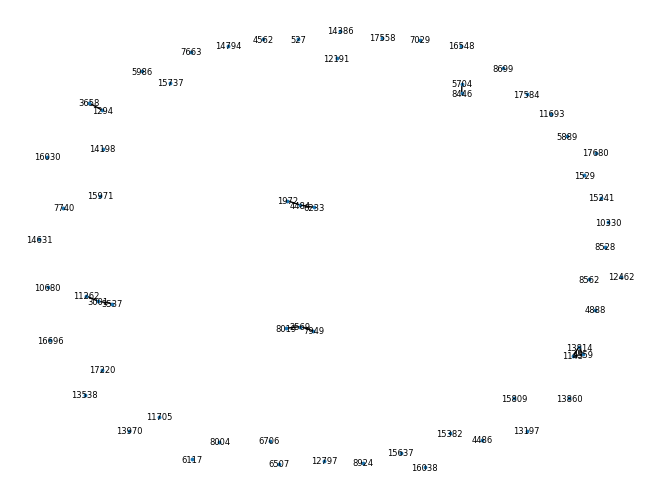

In [12]:
nodelist = symbol_pep_11
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_11")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_11_relayout")

C_DEBUG: sub_nodes: ['NPR1', 'AIF1L', 'HAUS5', 'GIMAP1', 'MCM6', 'ZNF699', 'CYBRD1', 'ZMYM3', 'SORCS2', 'SETDB2', 'TRDMT1', 'PAF1', 'SUPT5H', 'CASTOR3P', 'EDN2', 'ACVR1', 'ADK', 'NINJ2-AS1', 'NR1H2', 'JMY', 'ABCC1', 'VWA1', 'PCAT19', 'RUNX2', 'ANKRD27', 'EIF2AK1', 'EEIG1', 'CPED1', 'LINC01278', 'AMER1', 'YIF1B', 'KCNS1', 'SESN1', 'REEP4', 'PRPF3', 'MTURN', 'MFSD6', 'STPG1', 'C2orf88', 'NRG2', 'GAA', 'FGF10', 'MOSMO', 'POLR3D', 'RGL2', 'TACC3', 'ATE1', 'MXRA8', 'SCNN1B', 'ZNHIT6', 'BUB1', 'ZNF480', 'CFAP69', 'RBM42', 'NCCRP1', 'PLXNA3', 'MMP13', 'HSPBP1', 'IFI6', 'CNTNAP2', 'PTPN21', 'CTSF', 'PTGIS', 'AMIGO2', 'COX6B1', 'CDKN3', 'SMC1A', 'GALNS', 'UBE2S', 'EXOSC10', 'FAM135A', 'GGACT', 'OSR1', 'COL11A1', 'CDK16', 'EXO1', 'BIVM', 'EPHB2', 'ZNF444', 'RNF144B', 'PLK1', 'CCDC97', 'MFAP2', 'TIMM50', 'CREBL2', 'NEK2', 'ABTB1', 'BRIP1', 'UBE2T', 'FAF2', 'FAM83D', 'CCDC106', 'SCUBE1', 'MRGPRF', 'LSM1', 'HOXA-AS2', 'TMT1A', 'ATAD3A', 'SYNJ2BP', 'NEFH', 'PLPP5', 'ZC2HC1A', 'GSR', 'DDX41', 'PFKFB4

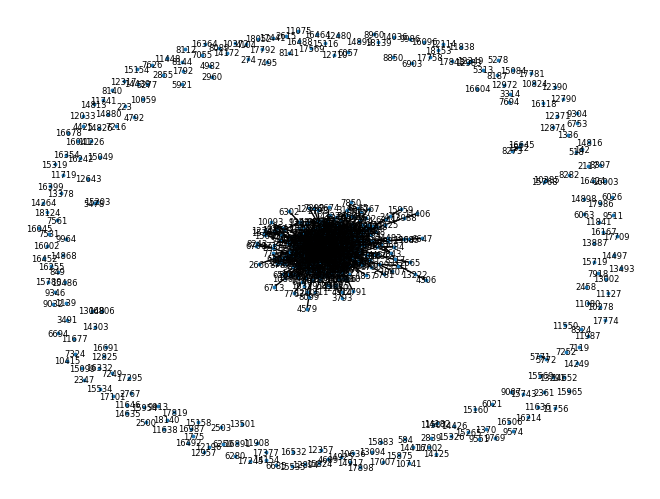

In [13]:
nodelist = symbol_pep_33
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_33")    
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_33_relayout")

C_DEBUG: sub_nodes: ['RAD51C', 'SLC2A10', 'COL5A2', 'TREML1', 'NLRP12', 'FAM114A1', 'TMEM126A', 'PIR', 'SMOC1', 'DNAJA4', 'STAT5B', 'RALBP1', 'RFC3', 'KAT6A', 'CFAP68', 'EVA1A', 'NFE2', 'NIF3L1', 'MPIG6B', 'ADGRG6', 'MAL2', 'CXADR', 'CLDN1', 'PSMG2', 'SNAI2', 'MARVELD2', 'IL33', 'RCN1', 'ITIH2', 'LRRC32-AS1', 'IFT70B', 'PRSS21', 'CFI', 'OLFML1', 'NFIB', 'FAM171A1', 'DYNC1H1', 'UBN1', 'RMDN2', 'RBBP9', 'TLE3', 'IGF1R', 'RBIS', 'RUNDC3A', 'CCR3', 'FOXA1', 'TFPI', 'SGCE', 'ART4', 'ITIH3', 'EPB42', 'BAZ2A', 'POSTN', 'DOCK1', 'DNALI1', 'IFT25', 'CCDC150', 'TBC1D14', 'AKR1C2', 'RPA3', 'FMO3', 'PARVA', 'TNFRSF8', 'ABCG5', 'NAT1', 'EBPL', 'FAM229B', 'NAT2', 'APOA4', 'RAB44', 'SLC6A6', 'COPZ2', 'CENPU', 'BPI', 'SCN9A', 'LYRM4', 'CHMP4C', 'FAM221A', 'BICD2', 'LINC02362', 'ZBTB8OS', 'SLC39A13-AS1', 'STAP2', 'GPR27', 'SERPIND1', 'SHISAL2A', 'INTS14', 'TM4SF4', 'SLC35A1', 'MED20', 'TPPP2', 'FKBP7', 'HMGN5', 'GPC6', 'MMP25', 'TMPPE', 'ORC5', 'FOXA3', 'NR1I2', 'PLB1', 'C13orf46', 'FRRS1', 'PEAK3', 'C

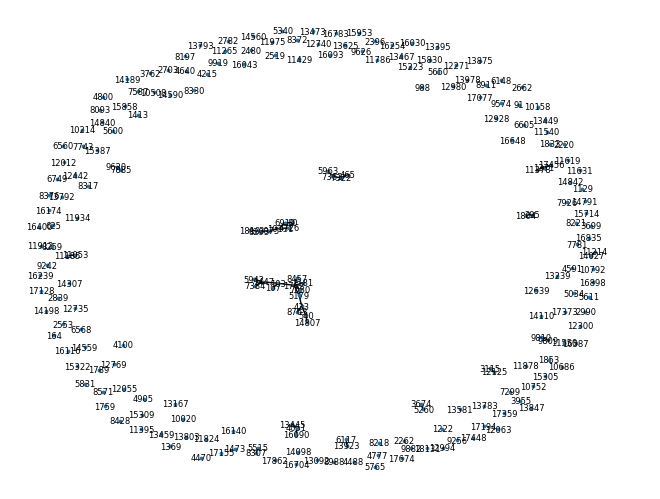

In [14]:
nodelist = symbol_pep_54
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_54")  
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_54_relayout")  

In [15]:
nodelist = symbol_pep_63
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name= "symbol_pep_63")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_63_relayout")

C_DEBUG: sub_nodes: ['IQGAP2', 'SMYD3', 'SSR1', 'SUMF2', 'TXNIP', 'CYBRD1', 'PAF1', 'SETDB2', 'IRF2', 'XBP1', 'MRFAP1', 'ST8SIA1', 'USP32', 'MYO1D', 'ETFBKMT', 'QSER1', 'SNRNP200', 'KDM5D', 'UBN1', 'KAT6B', 'USP25', 'ZNF331', 'MR1', 'YWHAQ', 'ATN1', 'BAZ2A', 'RABL3', 'KLF11', 'HIVEP2', 'TARBP2', 'EIF3F', 'FAM13C', 'RRP36', 'ANTKMT', 'ZBTB21', 'OSBPL11', 'SLC6A6', 'SLC37A2', 'ZNF324', 'HSPB8', 'CD2BP2-DT', 'JUN-DT', 'KDM6A', 'RPS18', 'PTGIS', 'ERCC4', 'NID2', 'ZNF200', 'GALE', 'KLHL25', 'MAN1B1', 'CYP3A5', 'DGLUCY', 'PHC2', 'RFTN1', 'FUT11', 'MRC2', 'AXL', 'SLC25A13', 'ESR1', 'DENND10', 'UBB', 'USP3', 'FZD1', 'MIATNB', 'ECM1', 'FOXO3', 'DCAF11', 'GOLGA2P10', 'DLG1', 'FCHO2', 'GPR155', 'ELN', 'MAP3K20', 'EEIG2', 'SRP9', 'METAP2', 'UTP4', 'RHOC', 'DCTD', 'SLAMF6', 'CRYZL2P', 'SLC38A6', 'GPR132', 'CHD7', 'RAB33B-AS1', 'PDE12', 'PDE12', 'SLC26A2', 'MAPRE1', 'EXOC8', 'ATL2', 'OAT', 'ATMIN', 'ARHGAP19', 'S1PR1', 'RPL38', 'FUCA1', 'OTUD4', 'IL16', 'SEL1L3', 'OGDHL', 'CLN5', 'MRPL55', 'ECM2', '

C_DEBUG: sub_nodes: ['CDCA5', 'SPSB2', 'SPSB2', 'KIF2C', 'BTG3', 'MYBL2', 'ESCO2', 'SLC1A5', 'MPP2', 'ACAT2', 'SLC30A10', 'CCNA2', 'MAL2', 'GINS3', 'HOXB13', 'KRT18', 'MARVELD2', 'H3C10', 'SGO1', 'KIF11', 'POMK', 'NCAPD2', 'H1-3', 'TRIP13', 'SNORA73B', 'H2AC20', 'GAN', 'NELL2', 'CCNB2', 'CDC20', 'F2RL1', 'FOXA1', 'FBN2', 'GFI1', 'DNAH14', 'MCM10', 'TROAP', 'E2F2', 'CCNB1', 'H1-4', 'ESRP2', 'H4C2', 'BUB1B', 'BUB1', 'HOXD10', 'H4C4', 'DSC3', 'RAB3B', 'GAS2L3', 'H3C2', 'EFNA5', 'RAB3GAP1', 'TRIM59', 'MAP7', 'LRRC75A', 'STK26', 'TICRR', 'PTTG1', 'RIPK4', 'SHROOM3', 'COCH', 'RHPN2', 'HACD3', 'SALL1', 'HOXB9', 'ORC1', 'MAD2L1', 'ZNF850', 'CDK1', 'APLP1', 'RN7SL3', 'KIF18B', 'KRT8', 'FOXM1', 'CDC45', 'RENO1', 'NEFL', 'DEPDC1B', 'H4C5', 'PIMREG', 'SLC27A5', 'SFXN2', 'CAMSAP3', 'NR6A1', 'EPCAM', 'CDC25C', 'CDS1', 'GTSE1', 'FLG', 'SCARNA5', 'EXO1', 'PRAME', 'NCR3LG1', 'ZWINT', 'HOOK1', 'PLK1', 'PCDH7', 'BIRC5', 'FGFR2', 'SAPCD2', 'CCNE2', 'NEK2', 'DMKN', 'GNG4', 'SNORD17', 'SCML2', 'RN7SL1', 'KI

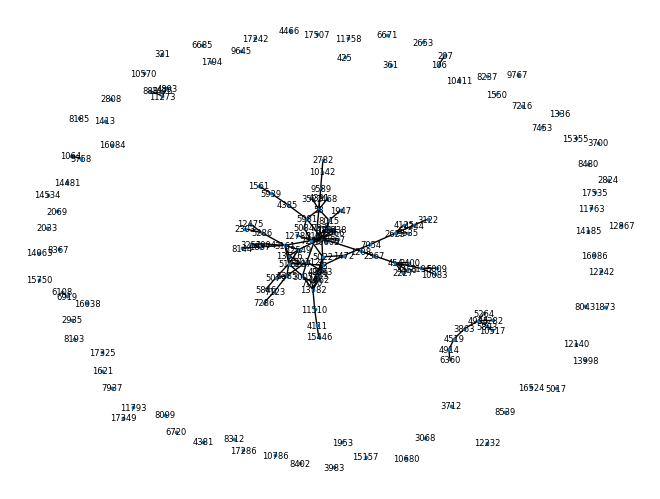

In [16]:
nodelist = symbol_pep_66
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_66")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_66_relayout")

C_DEBUG: sub_nodes: ['TRIM25', 'DNER', 'SAMD5', 'CCN4', 'VWCE', 'ITGA10', 'ANKMY1', 'EFR3A', 'F2R', 'TOX2', 'NIF3L1', 'ARRDC1-AS1', 'GRPEL1', 'EPB41L4A-AS1', 'LRMDA', 'GALNT7', 'SLC4A1AP', 'LINC02984', 'SLC9A5', 'MRAP2', 'SAT2', 'FOXN2', 'TIPIN', 'CHASERR', 'SCIMP', 'TTC13', 'QRICH2', 'SNAPC4', 'RASGEF1A', 'TVP23C', 'ZNF614', 'NUDT1', 'RUFY1', 'OGFRL1', 'METTL17', 'CDCA4', 'ZNF618', 'GRIN2A', 'CLN6', 'ZNF568', 'CILP2', 'GNB1L', 'FMOD', 'ADA2', 'CACNA1D', 'CPM', 'UBA1', 'COL11A1', 'ZFAT', 'GALNT11', 'ARHGEF10', 'C1orf35', 'CD22', 'CYP2R1', 'GAS5', 'RTN4RL1', 'ZNF420', 'AGO4', 'COL22A1', 'TRAPPC3', 'SMYD4', 'ASL', 'PCSK1N', 'FAM110A', 'EIF2B5', 'DDX41', 'DUSP4', 'BEND7', 'NUFIP1', 'NSDHL', 'SNHG7', 'SNHG7', 'TRAP1', 'SLC22A15', 'MAB21L2', 'PPP1R3G', 'PEX7', 'METAP1D', 'SLC25A37', 'POLD3', 'LINC02432', 'SAMD11', 'APP', 'MEOX1', 'ADAMTS6', 'SFR1', 'METAP1', 'RELN', 'STAC', 'LSAMP', 'TRAPPC2L', 'ZNF880', 'PLEKHA5', 'RFC2', 'PPP1CC', 'UQCRHL', 'ZNF383', 'ZFP91', 'SERP2', 'F2RL2', 'ZNF496', '

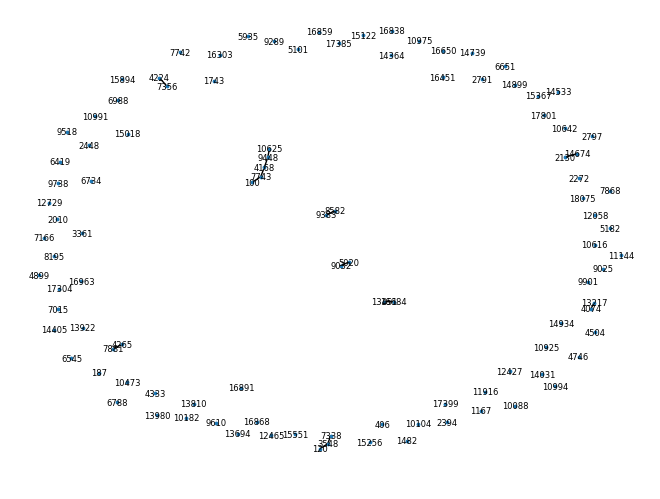

In [17]:
nodelist = symbol_pep_69
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_69")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_69_relayout")

C_DEBUG: sub_nodes: ['CLDN10', 'IL18BP', 'CXCL11', 'TENT5C', 'HLA-DPB1', 'TNFRSF17', 'ELMOD1', 'GSTO2', 'CARMIL2', 'SEPTIN1', 'KY', 'PIK3CD', 'IGKV3-15', 'CD8A', 'MRPS30-DT', 'HCLS1', 'IKZF3', 'SAMSN1', 'CD2', 'GAN', 'LILRB2', 'EAF2', 'IGLV3-9', 'PPIL6', 'WASL-DT', 'AOC3', 'HMGN4', 'PLA2G2D', 'GPR12', 'FAM13C', 'CD274', 'IFI6', 'TAGAP', 'RNF128', 'CYRIB', 'CYBA', 'IGHG4', 'IL21R', 'PYGL', 'UCP2', 'HLA-DRB1', 'PTGIS', 'DERL3', 'LINC00861', 'OSR1', 'MAGI1', 'PCED1B-AS1', 'NRXN1', 'MAOA', 'PAIP2B', 'PHYHIP', 'NDUFA10', 'FGF14', 'CORO1A', 'SIT1', 'IL12RB1', 'UBE2L6', 'PLEKHF2', 'MYRIP', 'PRF1', 'SSC5D', 'COL22A1', 'ARPC3', 'SLC9A2', 'IGKV1-5', 'IGLV4-69', 'FRY', 'GAREM1', 'CD38', 'IGLV8-61', 'SLAMF6', 'RNF180', 'PARD3B', 'RPH3AL', 'IGHV4-4', 'CD8B', 'MAP4K1', 'SYNPO2', 'SLAMF7', 'ARHGAP9', 'CLSTN2', 'NKRF', 'CGAS', 'IGLV3-21', 'KRT10-AS1', 'TNFRSF21', 'SPP1', 'SLA2', 'IGKV2D-29', 'IGLV3-25', 'PCDH19', 'SEL1L3', 'IGHV3-43', 'APOL1', 'SERPINB9', 'SEMA4D', 'IGHV4-31', 'PRELP', 'PAMR1', 'IGHV1

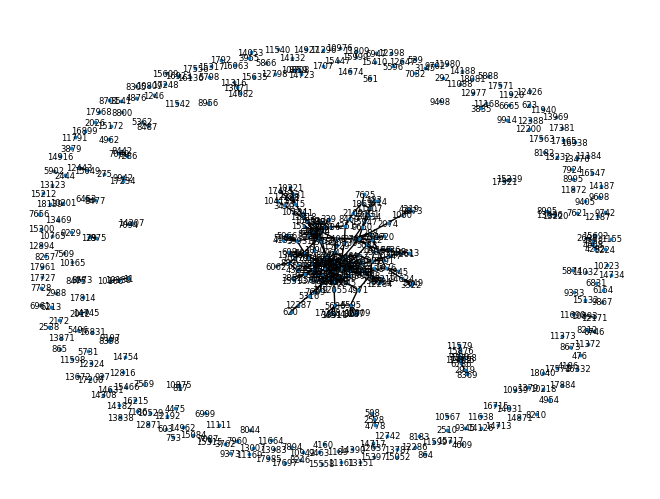

In [18]:
nodelist = symbol_pep_71
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_71")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_71_relayout")

C_DEBUG: sub_nodes: ['COMMD7', 'BCAS2', 'SLC29A3']
C_DEBUG: sub_nodes_ids: [7217, 11498, 17430]
C_DEBUG: subgraph number of edges: 0
None {7217: Text(-0.9982177048558978, 0.21260642469329752, '7217'), 11498: Text(0.8420033715015718, 0.7873935753067027, '11498'), 17430: Text(0.15621433335432605, -1.0, '17430')}


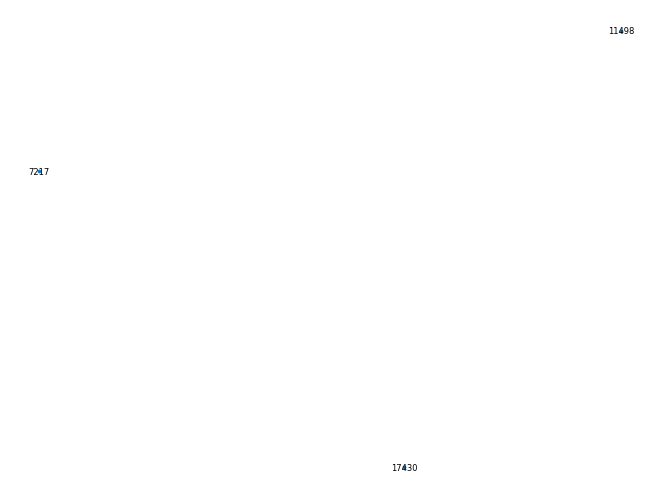

In [20]:
nodelist = symbol_pep_72
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_72")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_72_relayout")

C_DEBUG: sub_nodes: ['AIF1L', 'MT-ND5', 'AP1AR', 'BOLA1', 'JCAD', 'SLC1A5', 'RNF150', 'ALDH16A1', 'BLOC1S4', 'LY86', 'SHE', 'TMEM70', 'RSAD1', 'COBLL1', 'LINC02210', 'COX8A', 'ALKBH2', 'ADPRH', 'MR1', 'TIMM10', 'DHRS1', 'ATP5MC3', 'TBX2', 'NEDD8', 'ITGA1', 'GSTO1', 'ZNF672', 'ZBTB43', 'TRIM47', 'EIF2B2', 'FZD7', 'MT-CYB', 'MT-ND4', 'NANS', 'DDIT4L', 'ACP5', 'PALMD', 'SLC37A2', 'MT-ND2', 'CIAO3', 'BLTP1', 'C11orf71', 'SERGEF', 'DRAM2', 'CARMN', 'MT-CO2', 'BIRC6', 'MT-CO3', 'KLHL13', 'NBAS', 'GATA2', 'PPFIBP1', 'MRPS26', 'POGLUT1', 'TRPM6', 'MACROD1', 'RGS5', 'MECOM', 'ABCG2', 'TJP1', 'PTPRB', 'TMEM220', 'COG8', 'ZDHHC4', 'MT-RNR2', 'TYSND1', 'MT-CO1', 'GTPBP3', 'CD200', 'MAGEF1', 'ACP6', 'FILIP1', 'MT-ND4L', 'ABCB1', 'TPTEP1', 'TAFAZZIN', 'FLNB', 'OXLD1', 'LYSMD2', 'RPS27L', 'RP2', 'TNS1', 'ECRG4', 'NDUFB1', 'MST1', 'HDHD3', 'NEIL1', 'FHL5', 'COX5A', 'RGS10', 'ABCA8', 'LEPR', 'MCRIP2', 'CMTM3', 'FCGR2B', 'ELP5', 'TMEM267', 'C1D', 'ZNF273', 'DENND2D', 'MT-ND6', 'PSENEN', 'CEP43', 'TSPAN6

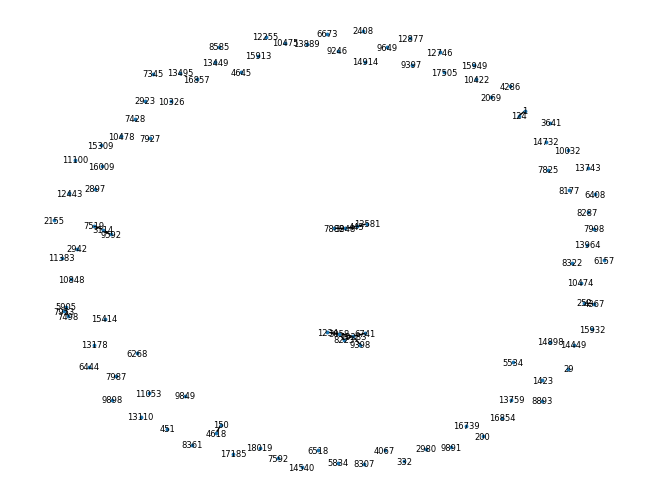

In [21]:
nodelist = symbol_pep_75
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name = "symbol_pep_75")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_75_relayout")

In [ ]:
session.reload_project() # to get back to initial state of project (incl. initial layout)